In [1]:
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Bidirectional
from keras.callbacks import ModelCheckpoint, TensorBoard
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
import yfinance as yf
from collections import deque

import os
import numpy as np
import pandas as pd
import random


In [2]:
# set seed, so we can get the same results after rerunning several times
np.random.seed(314)
tf.random.set_seed(314)
random.seed(314)


In [3]:
import os
import time
from keras.layers import LSTM

# Window size or the sequence length
N_STEPS = 50
# Lookup step, 1 is the next day
LOOKUP_STEP = 15

# whether to scale feature columns & output price as well
SCALE = True
scale_str = f"sc-{int(SCALE)}"
# whether to shuffle the dataset
SHUFFLE = True
shuffle_str = f"sh-{int(SHUFFLE)}"
# whether to split the training/testing set by date
SPLIT_BY_DATE = False
split_by_date_str = f"sbd-{int(SPLIT_BY_DATE)}"
# test ratio size, 0.2 is 20%
TEST_SIZE = 0.2
# features to use
FEATURE_COLUMNS = ["adjclose", "volume", "open", "high", "low"]
# date now
date_now = time.strftime("%Y-%m-%d")

### model parameters

N_LAYERS = 2
# LSTM cell
CELL = LSTM
# 256 LSTM neurons
UNITS = 256
# 40% dropout
DROPOUT = 0.4
# whether to use bidirectional RNNs
BIDIRECTIONAL = False

### training parameters

# huber loss (renamed from huber_loss in Keras 2.x+)
LOSS = "huber"
OPTIMIZER = "adam"
BATCH_SIZE = 64
EPOCHS = 20

# Amazon stock market
ticker = "AMZN"
ticker_data_filename = os.path.join("data", f"{ticker}_{date_now}.csv")
# model name to save, making it as unique as possible based on parameters
model_name = f"{date_now}_{ticker}-{shuffle_str}-{scale_str}-{split_by_date_str}-{LOSS}-{OPTIMIZER}-{CELL.__name__}-seq-{N_STEPS}-step-{LOOKUP_STEP}-layers-{N_LAYERS}-units-{UNITS}"
if BIDIRECTIONAL:
    model_name += "-b"


In [4]:
def shuffle_in_unison(a, b):
    # shuffle two arrays in the same way
    state = np.random.get_state()
    np.random.shuffle(a)
    np.random.set_state(state)
    np.random.shuffle(b)


def load_data(ticker, n_steps=50, scale=True, shuffle=True, lookup_step=1, split_by_date=True,
                test_size=0.2, feature_columns=['adjclose', 'volume', 'open', 'high', 'low']):
    """
    Loads data from Yahoo Finance source, as well as scaling, shuffling, normalizing and splitting.
    Params:
        ticker (str/pd.DataFrame): the ticker you want to load, examples include AAPL, TESL, etc.
        n_steps (int): the historical sequence length (i.e window size) used to predict, default is 50
        scale (bool): whether to scale prices from 0 to 1, default is True
        shuffle (bool): whether to shuffle the dataset (both training & testing), default is True
        lookup_step (int): the future lookup step to predict, default is 1 (e.g next day)
        split_by_date (bool): whether we split the dataset into training/testing by date, setting it
            to False will split datasets in a random way
        test_size (float): ratio for test data, default is 0.2 (20% testing data)
        feature_columns (list): the list of features to use to feed into the model, default is everything grabbed from yahoo finance
    """
    # see if ticker is already a loaded stock from yahoo finance
    if isinstance(ticker, str):
        # load it from yfinance
        raw = yf.download(ticker, period="max", auto_adjust=False)
        # yfinance returns MultiIndex columns; flatten and lowercase them
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = [col[0].lower() for col in raw.columns]
        else:
            raw.columns = [col.lower() for col in raw.columns]
        # yfinance uses "adj close" — rename to adjclose
        if "adj close" in raw.columns:
            raw.rename(columns={"adj close": "adjclose"}, inplace=True)
        df = raw
    elif isinstance(ticker, pd.DataFrame):
        # already loaded, use it directly
        df = ticker
    else:
        raise TypeError("ticker can be either a str or a `pd.DataFrame` instances")

    # this will contain all the elements we want to return from this function
    result = {}
    # we will also return the original dataframe itself
    result['df'] = df.copy()

    # make sure that the passed feature_columns exist in the dataframe
    for col in feature_columns:
        assert col in df.columns, f"'{col}' does not exist in the dataframe."

    # add date as a column
    if "date" not in df.columns:
        df["date"] = df.index

    if scale:
        column_scaler = {}
        # scale the data (prices) from 0 to 1
        for column in feature_columns:
            scaler = preprocessing.MinMaxScaler()
            df[column] = scaler.fit_transform(np.expand_dims(df[column].values, axis=1))
            column_scaler[column] = scaler

        # add the MinMaxScaler instances to the result returned
        result["column_scaler"] = column_scaler

    # add the target column (label) by shifting by `lookup_step`
    df['future'] = df['adjclose'].shift(-lookup_step)

    # last `lookup_step` columns contains NaN in future column
    # get them before droping NaNs
    last_sequence = np.array(df[feature_columns].tail(lookup_step))

    # drop NaNs
    df.dropna(inplace=True)

    sequence_data = []
    sequences = deque(maxlen=n_steps)

    for entry, target in zip(df[feature_columns + ["date"]].values, df['future'].values):
        sequences.append(entry)
        if len(sequences) == n_steps:
            sequence_data.append([np.array(sequences), target])

    # get the last sequence by appending the last `n_step` sequence with `lookup_step` sequence
    # for instance, if n_steps=50 and lookup_step=10, last_sequence should be of 60 (that is 50+10) length
    # this last_sequence will be used to predict future stock prices that are not available in the dataset
    last_sequence = list([s[:len(feature_columns)] for s in sequences]) + list(last_sequence)
    last_sequence = np.array(last_sequence).astype(np.float32)
    # add to result
    result['last_sequence'] = last_sequence

    # construct the X's and y's
    X, y = [], []
    for seq, target in sequence_data:
        X.append(seq)
        y.append(target)

    # convert to numpy arrays
    X = np.array(X)
    y = np.array(y)

    if split_by_date:
        # split the dataset into training & testing sets by date (not randomly splitting)
        train_samples = int((1 - test_size) * len(X))
        result["X_train"] = X[:train_samples]
        result["y_train"] = y[:train_samples]
        result["X_test"]  = X[train_samples:]
        result["y_test"]  = y[train_samples:]
        if shuffle:
            # shuffle the datasets for training (if shuffle parameter is set)
            shuffle_in_unison(result["X_train"], result["y_train"])
            shuffle_in_unison(result["X_test"], result["y_test"])
    else:
        # split the dataset randomly
        result["X_train"], result["X_test"], result["y_train"], result["y_test"] = train_test_split(X, y,
                                                                                test_size=test_size, shuffle=shuffle)

    # get the list of test set dates
    dates = result["X_test"][:, -1, -1]
    # retrieve test features from the original dataframe
    result["test_df"] = result["df"].loc[dates]
    # remove duplicated dates in the testing dataframe
    result["test_df"] = result["test_df"][~result["test_df"].index.duplicated(keep='first')]
    # remove dates from the training/testing sets & convert to float32
    result["X_train"] = result["X_train"][:, :, :len(feature_columns)].astype(np.float32)
    result["X_test"] = result["X_test"][:, :, :len(feature_columns)].astype(np.float32)

    return result


In [5]:
def create_model(sequence_length, n_features, units=256, cell=LSTM, n_layers=2, dropout=0.3,
                loss="mean_absolute_error", optimizer="rmsprop", bidirectional=False):
    model = Sequential()
    for i in range(n_layers):
        if i == 0:
            # first layer — use input_shape instead of deprecated batch_input_shape
            if bidirectional:
                model.add(Bidirectional(cell(units, return_sequences=True), input_shape=(sequence_length, n_features)))
            else:
                model.add(cell(units, return_sequences=True, input_shape=(sequence_length, n_features)))
        elif i == n_layers - 1:
            # last layer
            if bidirectional:
                model.add(Bidirectional(cell(units, return_sequences=False)))
            else:
                model.add(cell(units, return_sequences=False))
        else:
            # hidden layers
            if bidirectional:
                model.add(Bidirectional(cell(units, return_sequences=True)))
            else:
                model.add(cell(units, return_sequences=True))
        # add dropout after each layer
        model.add(Dropout(dropout))
    model.add(Dense(1, activation="linear"))
    model.compile(loss=loss, metrics=["mean_absolute_error"], optimizer=optimizer)
    return model


In [6]:
# create these folders if they does not exist
if not os.path.isdir("results"):
    os.mkdir("results")

if not os.path.isdir("logs"):
    os.mkdir("logs")

if not os.path.isdir("data"):
    os.mkdir("data")

# load the data
data = load_data(ticker, N_STEPS, scale=SCALE, split_by_date=SPLIT_BY_DATE,
                shuffle=SHUFFLE, lookup_step=LOOKUP_STEP, test_size=TEST_SIZE,
                feature_columns=FEATURE_COLUMNS)

# save the dataframe
data["df"].to_csv(ticker_data_filename)

# construct the model
model = create_model(N_STEPS, len(FEATURE_COLUMNS), loss=LOSS, units=UNITS, cell=CELL, n_layers=N_LAYERS,
                    dropout=DROPOUT, optimizer=OPTIMIZER, bidirectional=BIDIRECTIONAL)


[*********************100%***********************]  1 of 1 completed
c:\Users\Admin\Documents\GitHub\COS30018_Group3.1_OpenBuffet\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
# some keras callbacks
checkpointer = ModelCheckpoint(os.path.join("results", model_name + ".weights.h5"), save_weights_only=True, save_best_only=True, verbose=1)
tensorboard = TensorBoard(log_dir=os.path.join("logs", model_name))
# train the model and save the weights whenever we see
# a new optimal model using ModelCheckpoint
history = model.fit(data["X_train"], data["y_train"],
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(data["X_test"], data["y_test"]),
                    callbacks=[checkpointer, tensorboard],
                    verbose=1)


Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - loss: 0.0051 - mean_absolute_error: 0.0454
Epoch 1: val_loss improved from None to 0.00034, saving model to results\2026-05-31_AMZN-sh-1-sc-1-sbd-0-huber-adam-LSTM-seq-50-step-15-layers-2-units-256.weights.h5

Epoch 1: finished saving model to results\2026-05-31_AMZN-sh-1-sc-1-sbd-0-huber-adam-LSTM-seq-50-step-15-layers-2-units-256.weights.h5
91/91 ━━━━━━━━━━━━━━━━━━━━ 27s 264ms/step - loss: 0.0019 - mean_absolute_error: 0.0275 - val_loss: 3.4020e-04 - val_mean_absolute_error: 0.0129
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 6.1647e-04 - mean_absolute_error: 0.0176
Epoch 2: val_loss did not improve from 0.00034
91/91 ━━━━━━━━━━━━━━━━━━━━ 17s 188ms/step - loss: 6.0992e-04 - mean_absolute_error: 0.0177 - val_loss: 3.5120e-04 - val_mean_absolute_error: 0.0128
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - loss: 6.1175e-04 - mean_absolute_error: 0.0171
Epoch 3: val_loss did not improve from 0.00034
91/91 ━━━━━━━

In [8]:
import matplotlib.pyplot as plt

def plot_graph(test_df):
    """
    This function plots true close price along with predicted close price
    with blue and red colors respectively
    """
    plt.plot(test_df[f'true_adjclose_{LOOKUP_STEP}'], c='b')
    plt.plot(test_df[f'adjclose_{LOOKUP_STEP}'], c='r')
    plt.xlabel("Days")
    plt.ylabel("Price")
    plt.legend(["Actual Price", "Predicted Price"])
    plt.show()


In [9]:
def get_final_df(model, data):
    """
    This function takes the `model` and `data` dict to
    construct a final dataframe that includes the features along
    with true and predicted prices of the testing dataset
    """
    # if predicted future price is higher than the current,
    # then calculate the true future price minus the current price, to get the buy profit
    buy_profit  = lambda current, pred_future, true_future: true_future - current if pred_future > current else 0
    # if the predicted future price is lower than the current price,
    # then subtract the true future price from the current price
    sell_profit = lambda current, pred_future, true_future: current - true_future if pred_future < current else 0
    X_test = data["X_test"]
    y_test = data["y_test"]
    # perform prediction and get prices
    y_pred = model.predict(X_test)
    if SCALE:
        y_test = np.squeeze(data["column_scaler"]["adjclose"].inverse_transform(np.expand_dims(y_test, axis=0)))
        y_pred = np.squeeze(data["column_scaler"]["adjclose"].inverse_transform(y_pred))
    test_df = data["test_df"]
    # add predicted future prices to the dataframe
    test_df[f"adjclose_{LOOKUP_STEP}"] = y_pred
    # add true future prices to the dataframe
    test_df[f"true_adjclose_{LOOKUP_STEP}"] = y_test
    # sort the dataframe by date
    test_df.sort_index(inplace=True)
    final_df = test_df
    # add the buy profit column
    final_df["buy_profit"] = list(map(buy_profit,
                                    final_df["adjclose"],
                                    final_df[f"adjclose_{LOOKUP_STEP}"],
                                    final_df[f"true_adjclose_{LOOKUP_STEP}"])
                                    )
    # add the sell profit column
    final_df["sell_profit"] = list(map(sell_profit,
                                    final_df["adjclose"],
                                    final_df[f"adjclose_{LOOKUP_STEP}"],
                                    final_df[f"true_adjclose_{LOOKUP_STEP}"])
                                    )
    return final_df


In [10]:
def predict(model, data):
    # retrieve the last sequence from data
    last_sequence = data["last_sequence"][-N_STEPS:]
    # expand dimension
    last_sequence = np.expand_dims(last_sequence, axis=0)
    # get the prediction (scaled from 0 to 1)
    prediction = model.predict(last_sequence)
    # get the price (by inverting the scaling)
    if SCALE:
        predicted_price = data["column_scaler"]["adjclose"].inverse_transform(prediction)[0][0]
    else:
        predicted_price = prediction[0][0]
    return predicted_price


In [11]:
# load optimal model weights from results folder
model_path = os.path.join("results", model_name) + ".weights.h5"
model.load_weights(model_path)


In [12]:
# evaluate the model
loss, mae = model.evaluate(data["X_test"], data["y_test"], verbose=0)
# calculate the mean absolute error (inverse scaling)
if SCALE:
    mean_absolute_error = data["column_scaler"]["adjclose"].inverse_transform([[mae]])[0][0]
else:
    mean_absolute_error = mae


In [13]:
# get the final dataframe for the testing set
final_df = get_final_df(model, data)


46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step


In [14]:
# predict the future price
future_price = predict(model, data)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


In [15]:
# we calculate the accuracy by counting the number of positive profits
accuracy_score = (len(final_df[final_df['sell_profit'] > 0]) + len(final_df[final_df['buy_profit'] > 0])) / len(final_df)
# calculating total buy & sell profit
total_buy_profit  = final_df["buy_profit"].sum()
total_sell_profit = final_df["sell_profit"].sum()
# total profit by adding sell & buy together
total_profit = total_buy_profit + total_sell_profit
# dividing total profit by number of testing samples (number of trades)
profit_per_trade = total_profit / len(final_df)


In [16]:
# printing metrics
print(f"Future price after {LOOKUP_STEP} days is {future_price:.2f}$")
print(f"{LOSS} loss:", loss)
print("Mean Absolute Error:", mean_absolute_error)
print("Accuracy score:", accuracy_score)
print("Total buy profit:", total_buy_profit)
print("Total sell profit:", total_sell_profit)
print("Total profit:", total_profit)
print("Profit per trade:", profit_per_trade)


Future price after 15 days is 264.64$
huber loss: 0.00031207152642309666
Mean Absolute Error: 3.220146193020996
Accuracy score: 0.5783298826777088
Total buy profit: 823.2862479016186
Total sell profit: -25.49255499243729
Total profit: 797.7936929091813
Profit per trade: 0.550582258736495


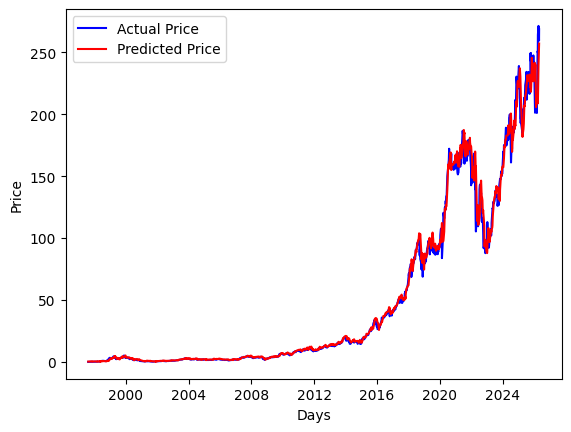

In [17]:
# plot true/pred prices graph
plot_graph(final_df)


In [18]:
final_df.head(20)


,adjclose,close,high,low,open,volume,adjclose_15,true_adjclose_15,buy_profit,sell_profit
Date,,,,,,,,,,
1997-08-06,0.112500,0.112500,0.115625,0.109375,0.110417,24864000,0.405923,0.115885,0.003385,0.0
1997-08-21,0.105729,0.105729,0.108594,0.103646,0.106771,12480000,0.447581,0.184375,0.078646,0.0
1997-09-03,0.116667,0.116667,0.120833,0.115625,0.117188,39288000,0.456258,0.218750,0.102083,0.0
1997-09-05,0.125000,0.125000,0.133333,0.122917,0.129167,38160000,0.434800,0.208333,0.083333,0.0
1997-09-10,0.165104,0.165104,0.166406,0.156250,0.165625,77328000,0.348152,0.201042,0.035938,0.0
1997-09-15,0.154688,0.154688,0.183854,0.152604,0.183333,111672000,0.383188,0.206250,0.051562,0.0
1997-09-17,0.170313,0.170313,0.175000,0.166667,0.172917,52152000,0.393899,0.200260,0.029947,0.0
1997-09-22,0.225000,0.225000,0.233854,0.197396,0.200000,338760000,0.403915,0.200000,-0.025000,0.0
1997-09-29,0.202083,0.202083,0.209375,0.197917,0.207292,47424000,0.432579,0.191146,-0.010937,0.0


In [19]:
final_df.tail(20)


,adjclose,close,high,low,open,volume,adjclose_15,true_adjclose_15,buy_profit,sell_profit
Date,,,,,,,,,,
2025-12-26,232.520004,232.520004,232.990005,231.179993,232.039993,15994700,230.111771,231.000000,0.000000,1.520004
2026-01-02,226.500000,226.500000,235.460007,224.699997,231.339996,51456200,231.252182,238.419998,11.919998,0.000000
2026-01-07,241.559998,241.559998,245.289993,239.520004,239.610001,42236500,234.064651,241.729996,0.000000,-0.169998
2026-01-14,236.649994,236.649994,241.279999,236.220001,241.149994,41410600,241.471054,222.690002,-13.959991,0.000000
2026-01-26,238.419998,238.419998,240.949997,237.539993,239.979996,32825500,235.811142,201.149994,0.000000,37.270004
2026-02-02,242.960007,242.960007,245.630005,238.169998,238.309998,37546100,239.939880,208.559998,0.000000,34.400009
2026-02-03,238.619995,238.619995,246.350006,235.449997,244.979996,53831300,240.034164,210.639999,-27.979996,0.000000
2026-02-09,208.720001,208.720001,212.809998,203.350006,208.970001,91178400,224.007538,208.729996,0.009995,0.000000
2026-02-10,206.960007,206.960007,212.649994,206.410004,208.800003,67175000,219.589676,216.820007,9.860001,0.000000


In [20]:
# save the final dataframe to csv-results folder
csv_results_folder = "csv-results"
if not os.path.isdir(csv_results_folder):
    os.mkdir(csv_results_folder)
csv_filename = os.path.join(csv_results_folder, model_name + ".csv")
final_df.to_csv(csv_filename)
